In [1]:
import torch
try:
    torch.backends.cudnn.benchmark = True
except Exception:
    pass
try:
    from transformers import enable_gradient_checkpointing
    enable_gradient_checkpointing()
except Exception:
    pass
print('Performance tweaks applied')


Performance tweaks applied


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [4]:
from datasets import load_dataset
ds = load_dataset("cardiffnlp/tweet_eval", "irony")

In [5]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2862
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 784
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 955
    })
})

In [6]:
import pandas as pd

df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test = pd.DataFrame(ds['test'])

df = pd.concat([df_train, df_val, df_test], ignore_index=True)

In [7]:
df.head()

,text,label
0,seeing ppl walking w/ crutches makes me really...,1
1,"look for the girl with the broken smile, ask h...",0
2,Now I remember why I buy books online @user #s...,1
3,@user @user So is he banded from wearing the c...,1
4,Just found out there are Etch A Sketch apps. ...,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    4601 non-null   str  
 1   label   4601 non-null   int64
dtypes: int64(1), str(1)
memory usage: 429.3 KB


In [9]:
df.shape

(4601, 2)

In [10]:
df['label'].value_counts()

label
0    2389
1    2212
Name: count, dtype: int64

<Axes: title={'center': 'Label Distribution'}, xlabel='label'>

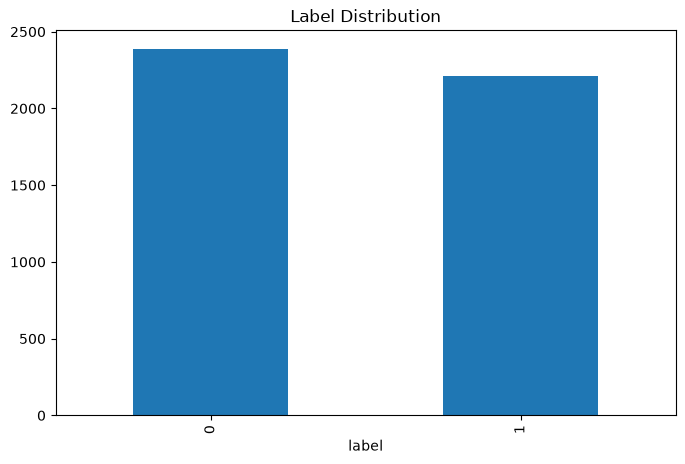

In [11]:
df['label'].value_counts().plot(kind='bar', title='Label Distribution', figsize=(8, 5))

In [12]:
dfb1 = pd.read_csv(r"C:\Users\Abdullah\Desktop\Code\Transfer Learning\Transfer Learning\Datasets\GEN-sarc-notsarc.csv")
dfb2 = pd.read_csv(r"C:\Users\Abdullah\Desktop\Code\Transfer Learning\Transfer Learning\Datasets\HYP-sarc-notsarc.csv")
dfb3 = pd.read_csv(r"C:\Users\Abdullah\Desktop\Code\Transfer Learning\Transfer Learning\Datasets\RQ-sarc-notsarc.csv")

In [13]:
dfb = pd.concat([dfb1, dfb2, dfb3], ignore_index=True)

In [14]:
dfb.head()

,class,id,text
0,notsarc,1,"If that's true, then Freedom of Speech is doom..."
1,notsarc,2,Neener neener - is it time to go in from the p...
2,notsarc,3,"Just like the plastic gun fear, the armour pie..."
3,notsarc,4,So geology is a religion because we weren't he...
4,notsarc,5,Well done Monty. Mark that up as your first ev...


In [15]:
dfb.sample(5)

,class,id,text
5190,sarc,5191,"no no! through the power of god, the animals a..."
6993,sarc,474,really? damn! i wanna be awesome too. are you ...
5798,notsarc,5799,"Well, your reasoning is certainly muddled, and..."
1741,notsarc,1742,Well he HAS admitted he can't prove his belief...
8507,sarc,824,how many counts would a recount count if a rec...


In [16]:
dfb.info()

<class 'pandas.DataFrame'>
RangeIndex: 9386 entries, 0 to 9385
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   9386 non-null   str  
 1   id      9386 non-null   int64
 2   text    9386 non-null   str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB


In [17]:
dfb.shape

(9386, 3)

In [18]:
dfb['class'] = dfb['class'].map({'notsarc' : 0, 'sarc' : 1})

In [19]:
dfb.sample(5)

,class,id,text
6684,0,165,no one believes this. this is a non-issue. i'm...
2712,1,2713,OOOHH!! Such ANGER!!!emoticonXAngry\r\nWhat is...
6012,1,6013,"I was thinking moreso Canada, Great Britain, a..."
6973,0,454,'whose illegal war? america isn't even there t...
2874,1,2875,"You still don't get it do you, Smiley... emoti..."


In [20]:
dfb['class'].map({'notsarc' : 0, 'sarc' : 1}).value_counts()

Series([], Name: count, dtype: int64)

In [21]:
df.columns.tolist()

['text', 'label']

In [22]:
dfb.columns.tolist()

['class', 'id', 'text']

In [23]:
dfb = dfb[['text', 'class']]

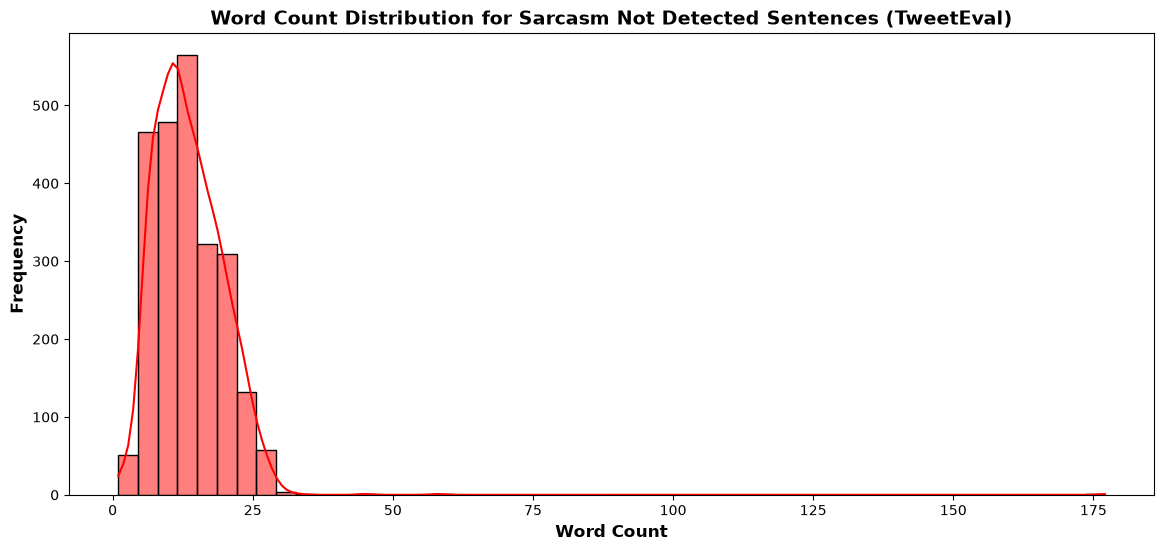

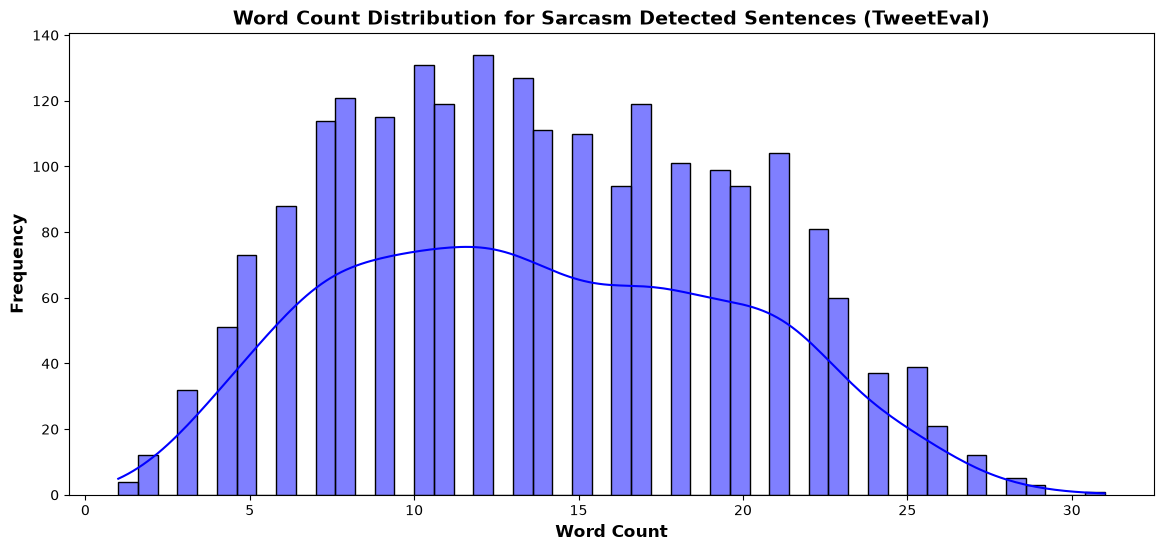

In [24]:
df['word_count'] = df['text'].astype(str).str.split().str.len()

plt.figure(figsize=(14, 6))
sns.histplot(df[df['label'] == 0]['word_count'], bins=50, color='red', kde=True)
plt.title('Word Count Distribution for Sarcasm Not Detected Sentences (TweetEval)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

plt.figure(figsize=(14, 6))
sns.histplot(df[df['label'] == 1]['word_count'], bins=50, color='blue', kde=True)
plt.title('Word Count Distribution for Sarcasm Detected Sentences (TweetEval)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

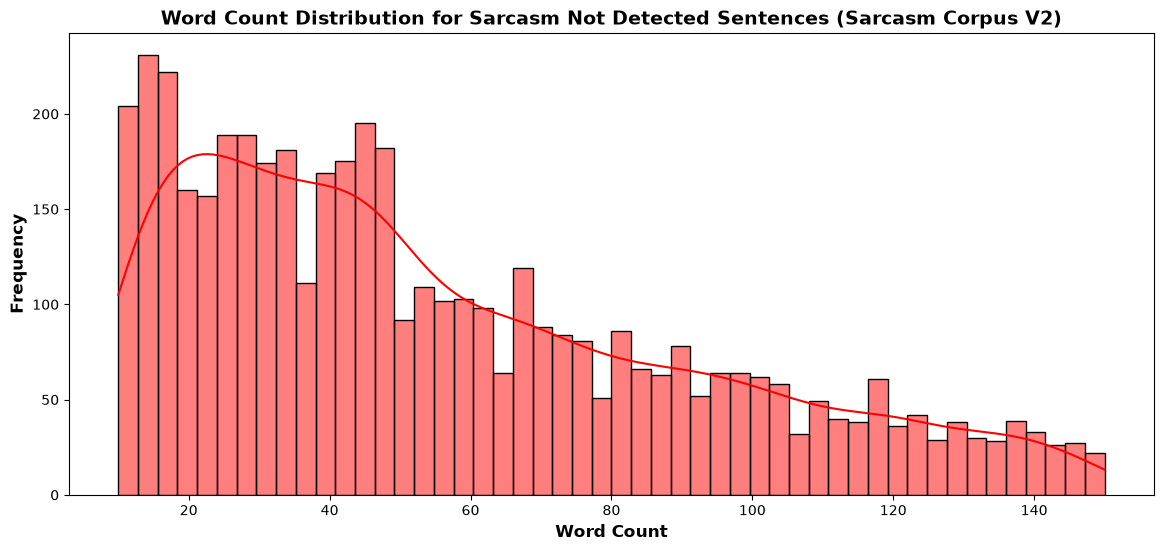

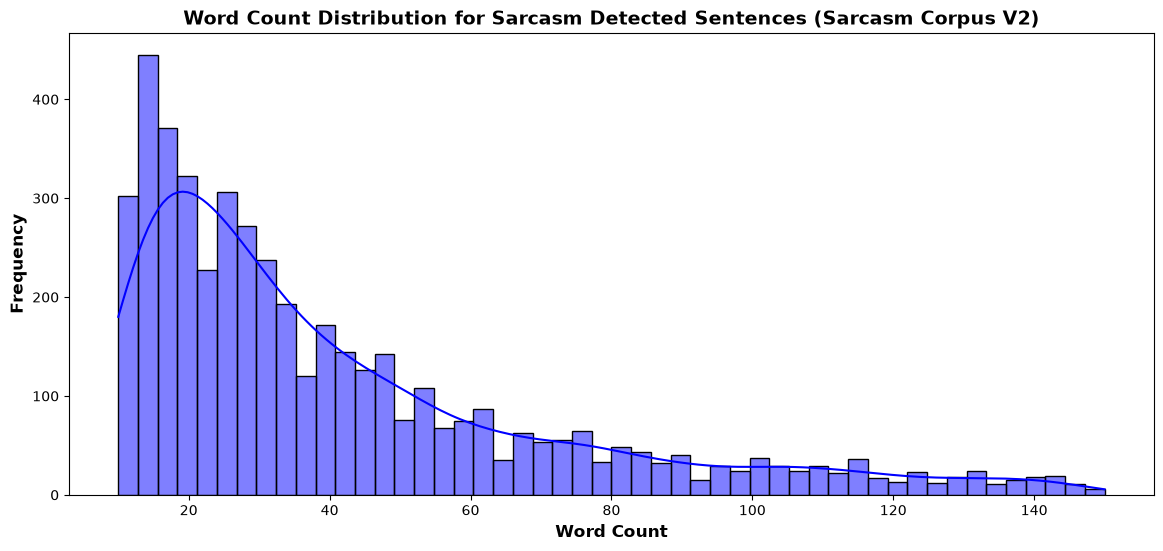

In [25]:
dfb['word_count'] = dfb['text'].astype(str).str.split().str.len()

plt.figure(figsize=(14, 6))
sns.histplot(dfb[dfb['class'] == 0]['word_count'], bins=50, color='red', kde=True)
plt.title('Word Count Distribution for Sarcasm Not Detected Sentences (Sarcasm Corpus V2)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

plt.figure(figsize=(14, 6))
sns.histplot(dfb[dfb['class'] == 1]['word_count'], bins=50, color='blue', kde=True)
plt.title('Word Count Distribution for Sarcasm Detected Sentences (Sarcasm Corpus V2)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

In [ ]:
print("Summary statistics for word counts per label:")
display(df.groupby('label')['word_count'].describe())

Summary statistics for word counts per label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,2389.0,13.661783,6.730413,1.0,9.0,13.0,18.0,177.0
1,2212.0,13.809675,5.980326,1.0,9.0,13.0,19.0,31.0


In [ ]:
print("Summary statistics for word counts per label:")
display(dfb.groupby('class')['word_count'].describe())

Summary statistics for word counts per label:


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,4693.0,55.770509,35.730168,10.0,27.0,46.0,79.0,150.0
1,4693.0,41.600256,30.821960,10.0,19.0,31.0,53.0,150.0


In [25]:
modelName = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(modelName)
print("Tokenizer initialized.", modelName)

Tokenizer initialized. xlm-roberta-base


In [26]:
sample_texts = df['text'].sample(500, random_state=42).tolist()
lengths = [len(tokenizer(t)['input_ids']) for t in sample_texts]

print(f"Mean:     {np.mean(lengths):.0f}")
print(f"Median:   {np.median(lengths):.0f}")
print(f"90th pct: {np.percentile(lengths, 90):.0f}")
print(f"95th pct: {np.percentile(lengths, 95):.0f}")
print(f"99th pct: {np.percentile(lengths, 99):.0f}")

MAX_LENGTH = 256
print(f"Using MAX_LENGTH = {MAX_LENGTH}")


Mean:     25
Median:   24
90th pct: 38
95th pct: 41
99th pct: 46
Using MAX_LENGTH = 256


In [27]:
sample_texts = dfb['text'].sample(500, random_state=42).tolist()
lengths = [len(tokenizer(t)['input_ids']) for t in sample_texts]

print(f"Mean:     {np.mean(lengths):.0f}")
print(f"Median:   {np.median(lengths):.0f}")
print(f"90th pct: {np.percentile(lengths, 90):.0f}")
print(f"95th pct: {np.percentile(lengths, 95):.0f}")
print(f"99th pct: {np.percentile(lengths, 99):.0f}")

MAX_LENGTH = 256
print(f"Using MAX_LENGTH = {MAX_LENGTH}")


Mean:     70
Median:   55
90th pct: 141
95th pct: 174
99th pct: 198
Using MAX_LENGTH = 256


In [28]:
df = df[['text', 'label']]

In [29]:
dfb = dfb[['text', 'class']]

In [30]:
train_a, test_a = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label']
)

print("Train size:", len(train_a))
print("Test size: ", len(test_a))
print("Train label distribution:", train_a['label'].value_counts().to_dict())
print("Test label distribution: ", test_a['label'].value_counts().to_dict())

Train size: 3680
Test size:  921
Train label distribution: {0: 1911, 1: 1769}
Test label distribution:  {0: 478, 1: 443}


In [31]:
def tokenize_fn(examples):
    text_column = 'news_clean' if 'news_clean' in examples else 'news' if 'news' in examples else 'text'
    texts = [str(t) if t is not None else "" for t in examples[text_column]]
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

In [32]:
from datasets import Dataset

train_ds_a = Dataset.from_pandas(train_a[['text', 'label']].reset_index(drop=True))
test_ds_a  = Dataset.from_pandas(test_a[['text', 'label']].reset_index(drop=True))

train_ds_a = train_ds_a.map(tokenize_fn, batched=True)
test_ds_a  = test_ds_a.map(tokenize_fn, batched=True)

train_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")
print("Train:", train_ds_a)
print("Test: ", test_ds_a)

Map:   0%|          | 0/3680 [00:00<?, ? examples/s]

Map:   0%|          | 0/921 [00:00<?, ? examples/s]

Tokenization done
Train: Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 3680
})
Test:  Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 921
})


In [33]:
from evaluate import load as load_metric

accuracy_metric = load_metric("accuracy")
f1_metric       = load_metric("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1":        f1_metric.compute(predictions=predictions, references=labels)["f1"],
    }

In [34]:
from transformers import TrainingArguments

training_args_1 = TrainingArguments(
    output_dir="./exp1_ax_to_grind",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
)


In [35]:
from transformers import AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

model_1 = AutoModelForSequenceClassification.from_pretrained(
    modelName,
    num_labels=2
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=train_ds_a,
    eval_dataset=test_ds_a,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_1.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.672234,0.637022,0.641694,0.563492
2,0.594117,0.652818,0.667752,0.695219
3,0.474527,0.620616,0.700326,0.699346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=690, training_loss=0.5768891790638799, metrics={'train_runtime': 376.6241, 'train_samples_per_second': 29.313, 'train_steps_per_second': 1.832, 'total_flos': 1452373025587200.0, 'train_loss': 0.5768891790638799, 'epoch': 3.0})

In [55]:
results_1 = trainer_1.evaluate(test_ds_a)
print("Experiment 1: In-domain TweetEval")   
print(results_1)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.531832,0.618147,3,0.685125,0.688172


Experiment 1: In-domain TweetEval
{'eval_loss': 0.6181473135948181, 'eval_accuracy': 0.6851248642779587, 'eval_f1': 0.6881720430107527}


In [57]:
print(f"dfb size before split: {len(dfb)}")

train_b, test_b = train_test_split(
    dfb,
    test_size=0.2,
    random_state=SEED,
    stratify=dfb['class']
)

print(f"After train_test_split - Train size: {len(train_b)}, Test size: {len(test_b)}")
print("Train class distribution:", train_b['class'].value_counts().to_dict())
print("Test class distribution: ", test_b['class'].value_counts().to_dict())
print(f"Train NaN in 'class' column: {train_b['class'].isna().sum()}")
print(f"Test NaN in 'class' column: {test_b['class'].isna().sum()}")

dfb size before split: 9386
After train_test_split - Train size: 7508, Test size: 1878
Train class distribution: {0: 3754, 1: 3754}
Test class distribution:  {0: 939, 1: 939}
Train NaN in 'class' column: 0
Test NaN in 'class' column: 0


In [ ]:
print(f"Before cleaning - Train size: {len(train_b)}, Test size: {len(test_b)}")

train_b_before = len(train_b)
test_b_before = len(test_b)

train_b = train_b.dropna(subset=['text', 'class']).copy()
test_b = test_b.dropna(subset=['text', 'class']).copy()

print(f"Rows dropped from train_b: {train_b_before - len(train_b)}")
print(f"Rows dropped from test_b: {test_b_before - len(test_b)}")

train_b['text'] = train_b['text'].astype(str)
test_b['text'] = test_b['text'].astype(str)

# Normalize the second dataset to the same label naming convention as the first one
train_b = train_b.rename(columns={'class': 'label'}).copy()
test_b = test_b.rename(columns={'class': 'label'}).copy()

print(f"After cleaning - Train size: {len(train_b)}, Test size: {len(test_b)}")

train_ds_b = Dataset.from_pandas(train_b[['text', 'label']].reset_index(drop=True))
test_ds_b  = Dataset.from_pandas(test_b[['text', 'label']].reset_index(drop=True))

train_ds_b = train_ds_b.map(tokenize_fn, batched=True)
test_ds_b  = test_ds_b.map(tokenize_fn, batched=True)

train_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")

In [60]:
from transformers import TrainingArguments

training_args_2 = TrainingArguments(
    output_dir="./fake-and-true-news-dataset",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=200,
    fp16=True,
    dataloader_num_workers=4,
)


In [61]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
print("Data collator initialized.")

Data collator initialized.


In [74]:
from evaluate import load
metric = load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

print("Compute metrics function defined.")

Compute metrics function defined.


In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

# Use the label column name expected by Trainer
if 'label' not in train_ds_b.column_names and 'labels' in train_ds_b.column_names:
    train_ds_b = train_ds_b.rename_column('labels', 'label')
if 'label' not in test_ds_b.column_names and 'labels' in test_ds_b.column_names:
    test_ds_b = test_ds_b.rename_column('labels', 'label')

train_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model_2 = AutoModelForSequenceClassification.from_pretrained(
    modelName,
    num_labels=2
)
try:
    model_2.gradient_checkpointing_enable()
except Exception:
    pass

trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_ds_b,
    eval_dataset=test_ds_b,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_2.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.546955,0.463157,0.787532
2,0.427558,0.462957,0.778281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=940, training_loss=0.49093802431796457, metrics={'train_runtime': 2052.5258, 'train_samples_per_second': 7.316, 'train_steps_per_second': 0.458, 'total_flos': 1975437803642880.0, 'train_loss': 0.49093802431796457, 'epoch': 2.0})

In [65]:
results_2 = trainer_2.evaluate(test_ds_b)
print("fake-and-true-news-dataset evaluation results:")
for k, v in results_2.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Training Loss,Validation Loss,Epoch,F1
0.427558,0.463157,2,0.787532


fake-and-true-news-dataset evaluation results:
  eval_loss: 0.4632
  eval_f1: 0.7875


In [37]:
full_ds_b = Dataset.from_pandas(dfb[['text', 'class']].reset_index(drop=True))
full_ds_b = full_ds_b.map(tokenize_fn, batched=True)
full_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'class'])

trainer_exp3 = Trainer(
    model=model_1,
    args=TrainingArguments(output_dir="./exp3", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_3 = trainer_exp3.evaluate(full_ds_b)
print("Experiment 3: Cross-domain A to B (trained on TweetEval, tested on Sentiment Corpus V2)")
for k, v in results_3.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/9386 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step
No log,No log,0


Experiment 3: Cross-domain A to B (trained on TweetEval, tested on Sentiment Corpus V2)


In [76]:
full_ds_a = Dataset.from_pandas(df[['text', 'label']].reset_index(drop=True))
full_ds_a = full_ds_a.map(tokenize_fn, batched=True)
full_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer_exp4 = Trainer(
    model=model_2,
    args=TrainingArguments(output_dir="./exp4", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_4 = trainer_exp4.evaluate(full_ds_a)
print("Experiment 4: Cross-domain B to A (trained on Sentiment Corpus V2, tested on TweetEval)")
for k, v in results_4.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/4601 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,F1
No log,1.070125,0,0.642260


Experiment 4: Cross-domain B to A (trained on Sentiment Corpus V2, tested on TweetEval)
  eval_loss: 1.0701
  eval_f1: 0.6423


In [26]:
import nltk
import re
import string
import html
from nltk.corpus import stopwords

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]+",
    flags=re.UNICODE,
)


def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)


def remove_emojis(text):
    return EMOJI_PATTERN.sub('', text)


def preprocess_text(text):
    text = str(text)
    text = html.unescape(text)
    text = remove_urls(text)
    text = remove_emojis(text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

print("Preprocessing df...")
df['news_clean'] = df['text'].apply(preprocess_text)
print("Preprocessing dfb...")
dfb['news_clean'] = dfb['text'].apply(preprocess_text)

print("Preprocessing complete!")
print("Sample of cleaned text from dfa:")
print(df['news_clean'].iloc[0][:200])

Preprocessing df...
Preprocessing dfb...
Preprocessing complete!
Sample of cleaned text from dfa:
seeing ppl walking crutches makes really excited next weeks life


In [27]:
train_a_tfidf, test_a_tfidf = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])

tfidf_a = TfidfVectorizer(max_features=10000)
X_train_a = tfidf_a.fit_transform(train_a_tfidf['news_clean'])
X_test_a  = tfidf_a.transform(test_a_tfidf['news_clean'])
y_train_a = train_a_tfidf['label']
y_test_a  = test_a_tfidf['label']

lr_a = LogisticRegression(max_iter=1000, random_state=SEED)
lr_a.fit(X_train_a, y_train_a)
lr_a_preds = lr_a.predict(X_test_a)
print("---- TF-IDF + Logistic Regression: TweetEval ----")
print(classification_report(y_test_a, lr_a_preds))

svm_a = SVC(kernel='linear', random_state=SEED)
svm_a.fit(X_train_a, y_train_a)
svm_a_preds = svm_a.predict(X_test_a)
print("---- TF-IDF + SVM: TweetEval ----")
print(classification_report(y_test_a, svm_a_preds))

---- TF-IDF + Logistic Regression: TweetEval ----
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       478
           1       0.68      0.58      0.63       443

    accuracy                           0.67       921
   macro avg       0.67      0.66      0.66       921
weighted avg       0.67      0.67      0.66       921

---- TF-IDF + SVM: TweetEval ----
              precision    recall  f1-score   support

           0       0.66      0.72      0.69       478
           1       0.67      0.60      0.63       443

    accuracy                           0.66       921
   macro avg       0.66      0.66      0.66       921
weighted avg       0.66      0.66      0.66       921



In [28]:
train_b_tfidf, test_b_tfidf = train_test_split(dfb, test_size=0.2, random_state=SEED, stratify=dfb['class'])

tfidf_b = TfidfVectorizer(max_features=10000)
X_train_b = tfidf_b.fit_transform(train_b_tfidf['news_clean'])
X_test_b  = tfidf_b.transform(test_b_tfidf['news_clean'])
y_train_b = train_b_tfidf['class']
y_test_b  = test_b_tfidf['class']

lr_b = LogisticRegression(max_iter=1000, random_state=SEED)
lr_b.fit(X_train_b, y_train_b)
lr_b_preds = lr_b.predict(X_test_b)
print("---- TF-IDF + Logistic Regression: DSentiment Corpus V2 ----")
print(classification_report(y_test_b, lr_b_preds))

svm_b = SVC(kernel='linear', random_state=SEED)
svm_b.fit(X_train_b, y_train_b)
svm_b_preds = svm_b.predict(X_test_b)
print("---- TF-IDF + SVM: Sentiment Corpus V2 ----")
print(classification_report(y_test_b, svm_b_preds))

---- TF-IDF + Logistic Regression: DSentiment Corpus V2 ----
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       939
           1       0.73      0.73      0.73       939

    accuracy                           0.73      1878
   macro avg       0.73      0.73      0.73      1878
weighted avg       0.73      0.73      0.73      1878

---- TF-IDF + SVM: Sentiment Corpus V2 ----
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       939
           1       0.72      0.70      0.71       939

    accuracy                           0.72      1878
   macro avg       0.72      0.72      0.72      1878
weighted avg       0.72      0.72      0.72      1878



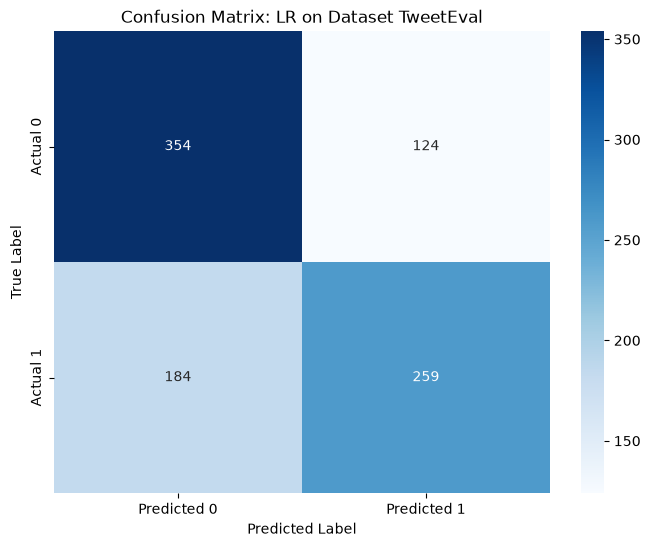

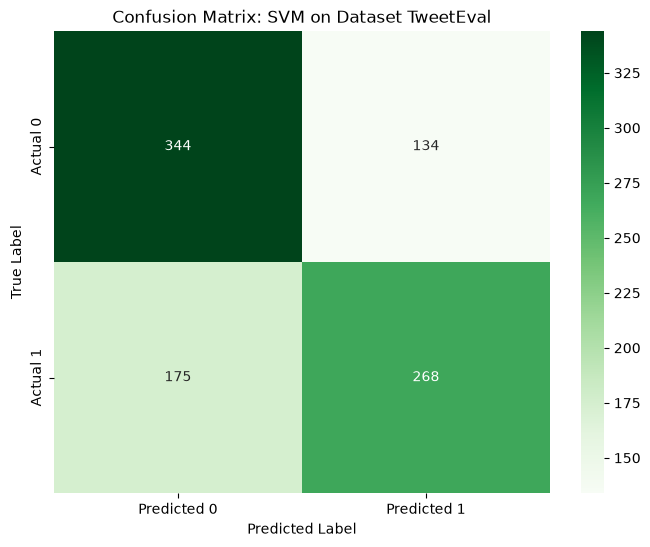

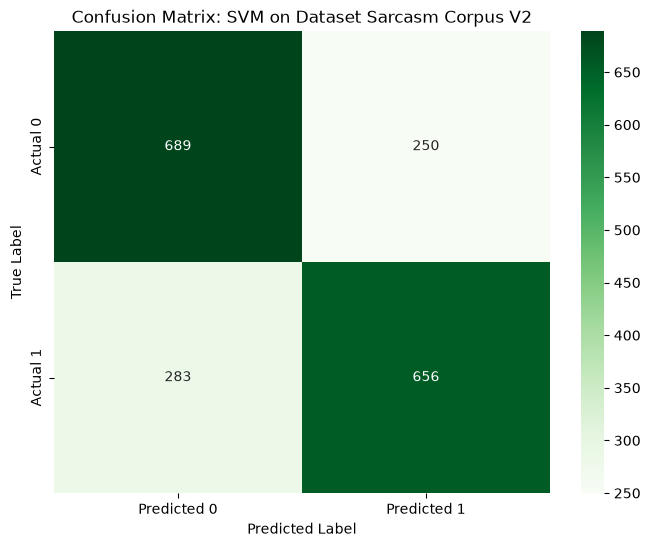

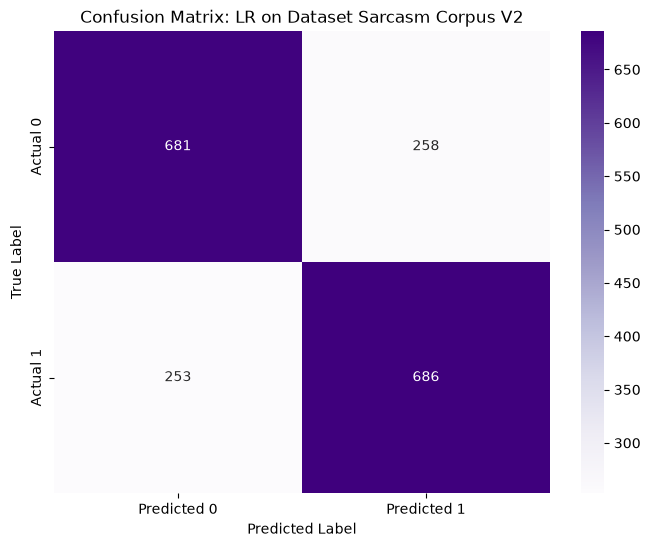

In [29]:
plt.figure(figsize=(8, 6))
cm_lr_a = confusion_matrix(y_test_a, lr_a_preds)
sns.heatmap(cm_lr_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset TweetEval')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(8, 6))
cm_svm_a = confusion_matrix(y_test_a, svm_a_preds)
sns.heatmap(cm_svm_a, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset TweetEval')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(8, 6))
cm_svm_b = confusion_matrix(y_test_b, svm_b_preds)
sns.heatmap(cm_svm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset Sarcasm Corpus V2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(8, 6))
cm_lr_b = confusion_matrix(y_test_b, lr_b_preds)
sns.heatmap(cm_lr_b, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset Sarcasm Corpus V2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
